In [27]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [28]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

In [29]:
x.shape


(100, 1)

In [30]:
y

array([  52.24931218,  -22.08667812,   -1.79638917,   59.11236635,
         62.19261977,  -10.72068023,  -35.18562673,  -45.9493215 ,
        -33.83241628,    2.04214282,  -66.8087827 ,   14.33666789,
          8.07602451,   57.52168234,  -15.41715303,   22.5077842 ,
        -12.35665275,   -7.52404953, -105.74150895,   15.44035512,
         47.35342054,   54.86877357,   34.31837282,    2.71066325,
        -55.90145551,  -64.58733049,  -66.87591286,  -32.66188461,
        -68.49422937,   48.69177555,   52.96079336,  -21.45852877,
         33.61089096,   68.74397989,   16.79102185,   12.61839641,
         -1.47304281,    6.73547129,   51.46755959,   43.64782865,
         75.31751861,    5.22677013,   -6.46673511,  -93.00434336,
         71.28502145,   -5.85091162,  -11.19674755,   64.80815138,
         -4.53334126,  -61.79067214,  -96.45564653,   16.76469001,
         90.69074286,    7.69209093,  -15.15382581,  -23.80616594,
        -88.6213497 ,   -1.16726246,  -58.03232991,   54.38298

In [31]:
y.shape

(100,)

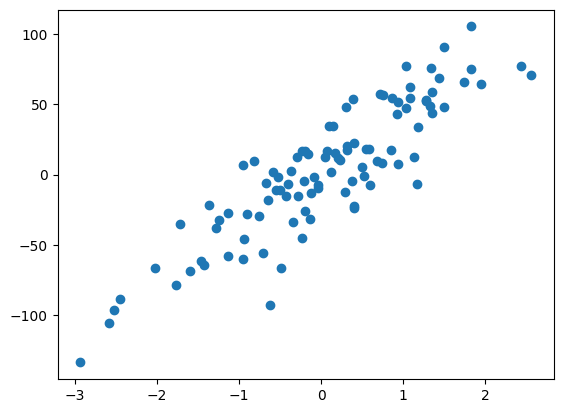

In [32]:
plt.scatter(x,y)

# Using SKlearn:->

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
x_train.shape

(80, 1)

In [35]:
x_test.shape

(20, 1)

In [57]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [58]:
from sklearn.metrics import r2_score
sky_pred=lr.predict(x_test)
r2_score(y_test,sky_pred)

0.8114934103343596

In [59]:
lr.intercept_

np.float64(-0.35434954570698557)

In [60]:
lr.coef_

array([38.76896898])

In [61]:
np.mean(cross_val_score(lr,x,y,scoring='r2',cv=10))

np.float64(0.7170231095763404)

# NOW OUR WON CLass for GRADIENT DECENT:

In [62]:
import numpy as np
class GDRegressor:
    def __init__(self,lerning_rate,epochs):
        self.m=100 # Randomly select
        self.b=-120 #Randomly select
        self.lr=lerning_rate
        self.epochs=epochs
    def fit(self,x,y):
        #calculation of the class
        for i in range(self.epochs):
            loss_slope_b=-2*np.sum(y-self.m*x.ravel()-self.b)
            loss_slope_m=-2*np.sum((y-self.m*x.ravel()-self.b)*x.ravel())
            self.b=self.b-(self.lr*loss_slope_b)
            self.m=self.m-(self.lr*loss_slope_m)
            
        print(self.b)
        print(self.m)
    def predict(self,x):
        return self.m*x+self.b
            
    



In [63]:
gd=GDRegressor(0.001,120)

In [64]:
gd.fit(x_test,y_test)   # this is same as the code sklearm

6.155383623608339
35.20571491305662


In [65]:
y_pred=gd.predict(x_test)

In [66]:
y_pred

array([[-56.14382774],
       [ 39.02120932],
       [ 32.53827857],
       [-17.58964839],
       [ 96.17357964],
       [ 53.75138458],
       [ 11.10388093],
       [ 29.97718706],
       [-65.2597139 ],
       [ 51.27484407],
       [-85.01836979],
       [ 51.05477181],
       [-22.51131104],
       [ 56.86417621],
       [ 42.52400001],
       [ 44.43249027],
       [ 17.24586977],
       [ -8.01216799],
       [ 32.17862098],
       [-41.97287936]])

In [67]:
y_test

array([ -78.968768  ,    7.69209093,   56.9006775 ,   -5.85091162,
         71.28502145,   43.64782865,   34.31837282,    9.69610071,
        -66.8087827 ,   52.24931218, -105.74150895,   52.96079336,
          9.56913931,   68.74397989,   77.19465884,   62.19261977,
         17.25793975,   -7.0666027 ,    8.07602451,  -21.45852877])

In [68]:
r2_score(y_test,y_pred)

0.8407406702279052